In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense, LayerNormalization, MultiHeadAttention, Add, Reshape, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import Input
import os

In [3]:
# Set dataset path
data_dir = r'D:\Project\data_kaggle\aug\train_split'

In [4]:
batch_size = 32
img_height = 224
img_width = 224
image_size = (img_height, img_width)
epochs = int(input("Enter epochs number: "))

Enter epochs number:  100


In [5]:
train_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb'  # Force RGB mode
)

Found 5863 images belonging to 8 classes.


In [6]:
val_datagen = ImageDataGenerator()

val_data = r"D:\Project\data_kaggle\aug\val_split"

val_generator = val_datagen.flow_from_directory(
    val_data,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
)

Found 1469 images belonging to 8 classes.


In [7]:
def create_cnn_base(input_shape):
    inputs = Input(shape=input_shape)

    # First Conv Block
    x = Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)

    # Second Conv Block
    x = Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.4)(x)

    # Third Conv Block
    x = Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.5)(x)

    return inputs, x

def transformer_encoder(inputs, num_heads, key_dim, ff_dim, dropout_rate=0.1):
    # Layer Normalization and Multi-Head Attention
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout_rate)(x, x)
    x = Dropout(dropout_rate)(x)
    x = Add()([x, inputs])

    # Feed Forward Network
    y = LayerNormalization(epsilon=1e-6)(x)
    y = Dense(ff_dim, activation='relu')(y)
    y = Dropout(dropout_rate)(y)
    y = Dense(inputs.shape[-1])(y)
    outputs = Add()([y, x])

    return outputs

def create_hybrid_model(input_shape, num_classes, num_transformer_blocks=1, num_heads=4, key_dim=128, ff_dim=256, dropout_rate=0.1):
    inputs, cnn_output = create_cnn_base(input_shape)

    # Reshape CNN output for Transformer
    x = Reshape((-1, cnn_output.shape[-1]))(cnn_output)

    # Apply Transformer blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, num_heads, key_dim, ff_dim, dropout_rate)

    # Global Average Pooling
    x = GlobalAveragePooling2D()(cnn_output)

    # Fully Connected Layer
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

input_shape = (224, 224, 3)
num_classes = len(train_generator.class_indices)

model = create_hybrid_model(input_shape, num_classes)

In [8]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 222, 222, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 111, 111, 32)      0         
_________________________________________________________________
dropout (Dropout)            (None, 111, 111, 32)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 109, 109, 64)      18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 54, 54, 64)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 54, 54, 64)        0     

In [9]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
# Train the model
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)

Epoch 1/100
184/184 [==============================] - 86s 355ms/step - loss: 3.3451 - accuracy: 0.2485 - val_loss: 2.1035 - val_accuracy: 0.3581
Epoch 2/100
184/184 [==============================] - 47s 253ms/step - loss: 1.9142 - accuracy: 0.3821 - val_loss: 1.8690 - val_accuracy: 0.4282
Epoch 3/100
184/184 [==============================] - 46s 247ms/step - loss: 1.7645 - accuracy: 0.4325 - val_loss: 1.7598 - val_accuracy: 0.4547
Epoch 4/100
184/184 [==============================] - 47s 252ms/step - loss: 1.6632 - accuracy: 0.4801 - val_loss: 1.6376 - val_accuracy: 0.4711
Epoch 5/100
184/184 [==============================] - 47s 253ms/step - loss: 1.5738 - accuracy: 0.5052 - val_loss: 1.6122 - val_accuracy: 0.4724
Epoch 6/100
184/184 [==============================] - 47s 253ms/step - loss: 1.4785 - accuracy: 0.5448 - val_loss: 1.4454 - val_accuracy: 0.5473
Epoch 7/100
184/184 [==============================] - 47s 252ms/step - loss: 1.4105 - accuracy: 0.5678 - val_loss: 1.5613 -

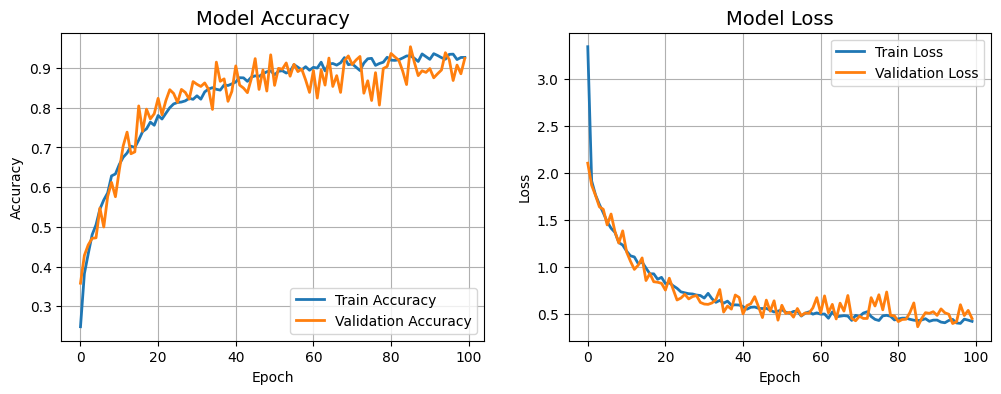

In [11]:
# Plot accuracy and loss curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [12]:
# Evaluate model
test_data = r'D:\Project\data_kaggle\test'

eval_generator = train_datagen.flow_from_directory(
    test_data,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

y_true = eval_generator.classes
y_pred = model.predict(eval_generator)

# Convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)  # Fix tf.argmax issue

Found 190 images belonging to 8 classes.


In [13]:
# Print classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred_classes))

# Plot confusion matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)
class_labels = list(train_generator.class_indices.keys())


Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        28
           1       0.61      0.81      0.69        21
           2       0.95      0.84      0.89        25
           3       0.76      0.83      0.79        23
           4       0.66      0.90      0.76        21
           5       0.91      0.43      0.59        23
           6       0.92      0.85      0.88        26
           7       0.95      0.91      0.93        23

    accuracy                           0.83       190
   macro avg       0.84      0.82      0.82       190
weighted avg       0.85      0.83      0.82       190



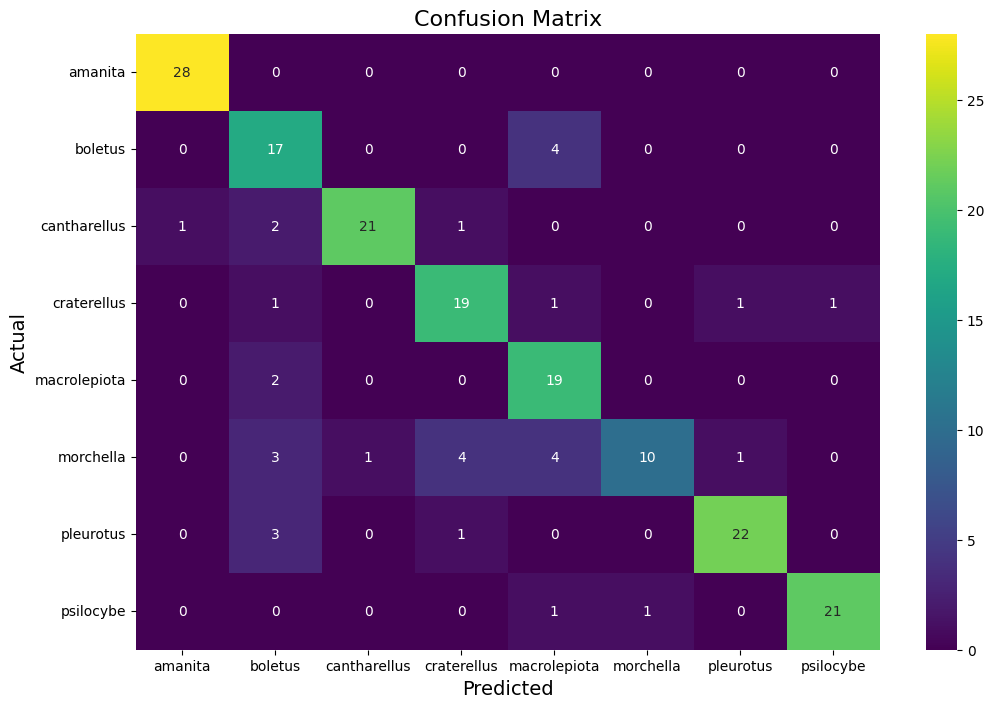

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="viridis", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.show()

In [15]:
model_version = epochs
next_version = str(int(model_version) + 10)

In [16]:
import shutil

notebook_filename = f"CNN_{model_version}_ADAM.ipynb"
new_notebook_filename = f"CNN_{next_version}_ADAM.ipynb"

shutil.copy(notebook_filename, new_notebook_filename)
print(f"Notebook copied as {new_notebook_filename}")

Notebook copied as CNN_110_ADAM.ipynb


In [ ]:
os._exit(00)